In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


   time      value      lag_1      lag_2  rolling_mean  rolling_std  anomaly
0     0  50.993428  70.931068  70.661865     56.137024      3.54544      0.0
1     1  51.026804  50.993428  70.931068     56.137024      3.54544      0.0
2     2  53.882276  51.026804  50.993428     56.137024      3.54544      0.0
3     3  56.877305  53.882276  51.026804     56.137024      3.54544      0.0
4     4  54.549230  56.877305  53.882276     56.137024      3.54544      0.0


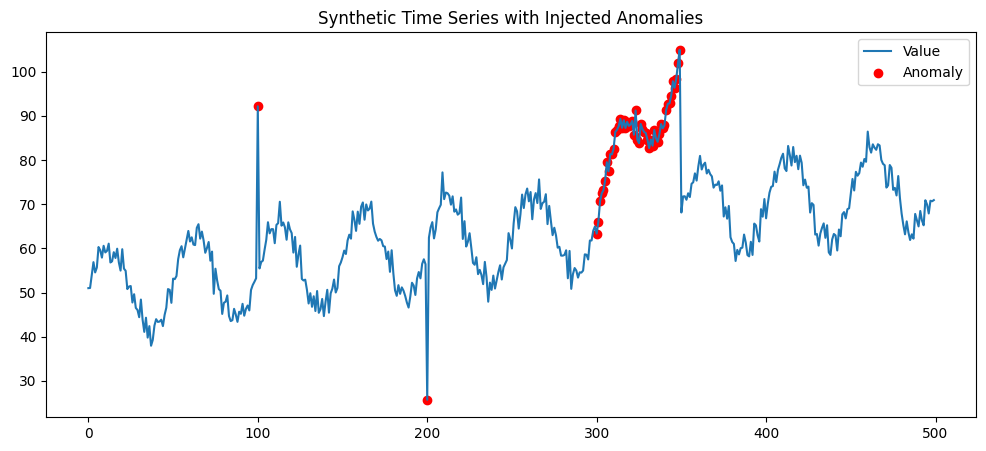

In [6]:
# =========================
# LEVEL 1: DATA GENERATION
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# -------------------------
# Step 1: Create time index
# -------------------------
n = 500
time = np.arange(n)

# -------------------------
# Step 2: Create base signals
# -------------------------

# Trend
trend = 0.05 * time

# Seasonality (sin wave)
seasonality = 10 * np.sin(2 * np.pi * time / 50)

# Noise
noise = np.random.normal(0, 2, n)

# Base signal (normal behavior)
value = 50 + trend + seasonality + noise

# -------------------------
# Step 3: Inject anomalies
# -------------------------

anomaly_labels = np.zeros(n)

# Spike anomaly
value[100] += 40
anomaly_labels[100] = 1

# Drop anomaly
value[200] -= 35
anomaly_labels[200] = 1

# Drift anomaly (gradual increase)
for i in range(300, 350):
    value[i] += (i - 300) * 0.8
    anomaly_labels[i] = 1

# -------------------------
# Step 4: Create extra features
# -------------------------

df = pd.DataFrame({
    "time": time,
    "value": value,
    "lag_1": np.roll(value, 1),
    "lag_2": np.roll(value, 2)
})

df["rolling_mean"] = df["value"].rolling(window=10).mean()
df["rolling_std"] = df["value"].rolling(window=10).std()

df["anomaly"] = anomaly_labels

# Fill NaNs
df.bfill(inplace=True)

# -------------------------
# Step 5: Show data
# -------------------------

print(df.head())

# -------------------------
# Step 6: Plot
# -------------------------

plt.figure(figsize=(12,5))
plt.plot(df["time"], df["value"], label="Value")

# highlight anomalies
plt.scatter(df[df["anomaly"]==1]["time"],
            df[df["anomaly"]==1]["value"],
            color='red', label="Anomaly")

plt.title("Synthetic Time Series with Injected Anomalies")
plt.legend()
plt.show()

In [7]:
print("Total anomalies:", df["anomaly"].sum())

Total anomalies: 52.0


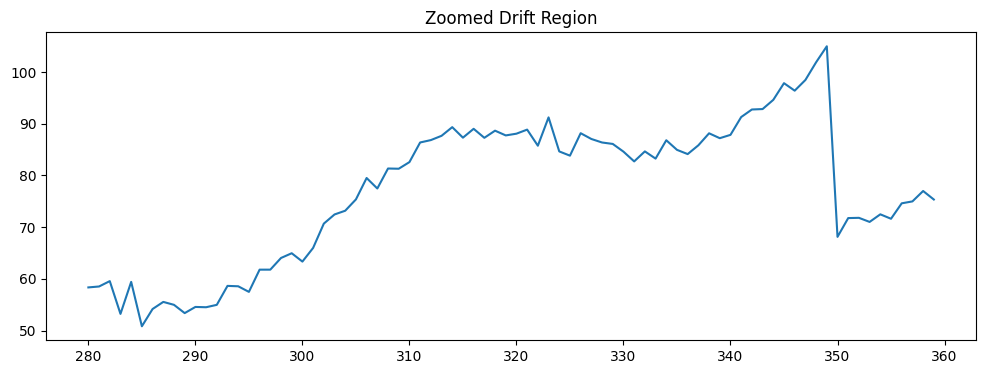

In [8]:
plt.figure(figsize=(12,4))
plt.plot(df["time"][280:360], df["value"][280:360])
plt.title("Zoomed Drift Region")
plt.show()

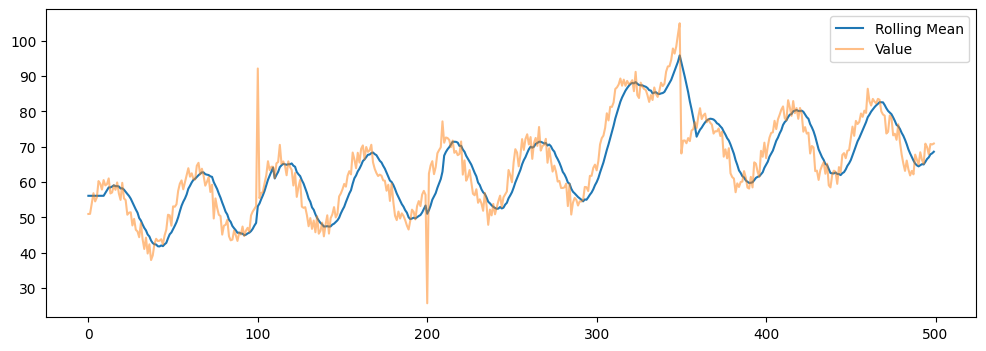

In [9]:
plt.figure(figsize=(12,4))
plt.plot(df["rolling_mean"], label="Rolling Mean")
plt.plot(df["value"], alpha=0.5, label="Value")
plt.legend()
plt.show()

In [10]:
# =========================
# LEVEL 2: ANOMALY DETECTION
# =========================

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# -------------------------
# Step 1: Select features
# -------------------------

features = ["value", "lag_1", "lag_2", "rolling_mean", "rolling_std"]
X = df[features]

# -------------------------
# Step 2: Scale data
# -------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# Step 3: Train model
# -------------------------

model = IsolationForest(
    n_estimators=100,
    contamination=0.1,   # expected anomaly %
    random_state=42
)

model.fit(X_scaled)

# -------------------------
# Step 4: Predictions
# -------------------------

# -1 = anomaly, 1 = normal
df["pred"] = model.predict(X_scaled)

# Convert to 0/1
df["pred"] = df["pred"].apply(lambda x: 1 if x == -1 else 0)

# anomaly score (higher = more abnormal)
df["score"] = -model.decision_function(X_scaled)

# -------------------------
# Step 5: Preview
# -------------------------

print(df[["value", "anomaly", "pred", "score"]].head())

       value  anomaly  pred     score
0  50.993428      0.0     0 -0.028594
1  51.026804      0.0     0 -0.059149
2  53.882276      0.0     0 -0.113743
3  56.877305      0.0     0 -0.117328
4  54.549230      0.0     0 -0.125041


In [11]:
print("Predicted anomalies:", df["pred"].sum())

Predicted anomalies: 50


In [12]:
from sklearn.metrics import classification_report

print(classification_report(df["anomaly"], df["pred"]))

              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93       448
         1.0       0.40      0.38      0.39        52

    accuracy                           0.88       500
   macro avg       0.66      0.66      0.66       500
weighted avg       0.87      0.88      0.87       500



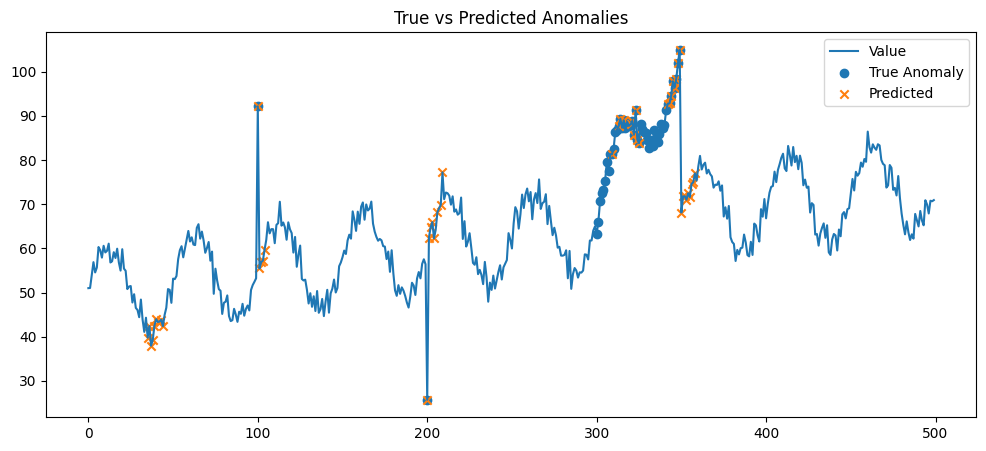

In [13]:
plt.figure(figsize=(12,5))

plt.plot(df["time"], df["value"], label="Value")

# ground truth
plt.scatter(df[df["anomaly"]==1]["time"],
            df[df["anomaly"]==1]["value"],
            label="True Anomaly")

# predicted
plt.scatter(df[df["pred"]==1]["time"],
            df[df["pred"]==1]["value"],
            marker='x',
            label="Predicted")

plt.legend()
plt.title("True vs Predicted Anomalies")
plt.show()

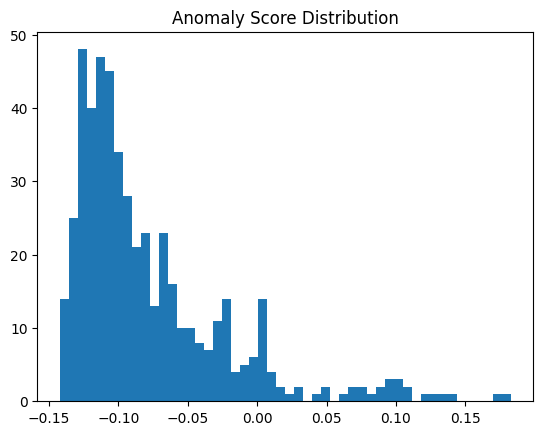

In [14]:
plt.figure()
plt.hist(df["score"], bins=50)
plt.title("Anomaly Score Distribution")
plt.show()

In [40]:
# =========================
# LEVEL 3: TEMPORAL ANALYSIS (FINAL)
# =========================

import numpy as np

# -------------------------
# Step 1: Basic signals
# -------------------------

df["diff"] = df["value"].diff().fillna(0)

# -------------------------
# Step 2: Thresholds (adaptive)
# -------------------------

diff_threshold = df["diff"].std() * 2
slope_threshold = df["value"].std() * 0.01
change_threshold = df["value"].std() * 0.5

# -------------------------
# Step 3: Initialize
# -------------------------

df["anomaly_type"] = "normal"

# -------------------------
# Step 4: Classification logic
# -------------------------

for i in range(len(df)):

    if df.loc[i, "pred"] == 1:  # only predicted anomalies

        # -------------------------
        # 1. SPIKE detection
        # -------------------------
        if abs(df.loc[i, "diff"]) > diff_threshold:
            df.loc[i, "anomaly_type"] = "spike"

        else:
            # -------------------------
            # 2. WINDOW for temporal analysis
            # -------------------------
            start = max(0, i-10)
            window_vals = df["value"].iloc[start:i+1]

            if len(window_vals) < 3:
                df.loc[i, "anomaly_type"] = "seasonal"
                continue

            # -------------------------
            # 3. TREND detection (slope)
            # -------------------------
            x = np.arange(len(window_vals))
            y = window_vals.values

            slope = np.polyfit(x, y, 1)[0]
            trend_present = abs(slope) > slope_threshold

            # -------------------------
            # 4. CUMULATIVE CHANGE
            # -------------------------
            total_change = window_vals.iloc[-1] - window_vals.iloc[0]
            significant_change = abs(total_change) > change_threshold

            # -------------------------
            # 5. FINAL classification
            # -------------------------
            if trend_present and significant_change:
                df.loc[i, "anomaly_type"] = "drift"
            else:
                df.loc[i, "anomaly_type"] = "seasonal"

# -------------------------
# Step 5: Preview
# -------------------------

print(df[["value", "pred", "anomaly_type"]].head(20))

        value  pred anomaly_type
0   50.993428     0       normal
1   51.026804     0       normal
2   53.882276     0       normal
3   56.877305     0       normal
4   54.549230     0       normal
5   55.659579     0       normal
6   60.303897     0       normal
7   59.590002     0       normal
8   57.904330     0       normal
9   60.583391     0       normal
10  59.083730     0       normal
11  59.441413     0       normal
12  61.064192     0       normal
13  56.803707     0       normal
14  57.073037     0       normal
15  59.135990     0       normal
16  57.822608     0       normal
17  59.921774     0       normal
18  56.789084     0       normal
19  54.970864     0       normal


In [41]:
print(df["anomaly_type"].value_counts())

anomaly_type
normal      450
drift        32
seasonal     13
spike         5
Name: count, dtype: int64


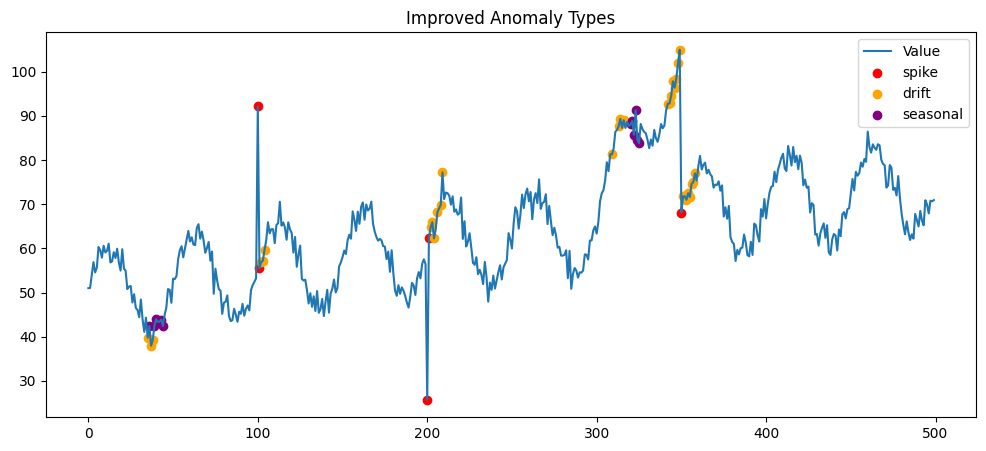

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["time"], df["value"], label="Value")

colors = {
    "spike": "red",
    "drift": "orange",
    "seasonal": "purple"
}

for t, c in colors.items():
    subset = df[df["anomaly_type"] == t]
    plt.scatter(subset["time"], subset["value"], label=t, color=c)

plt.legend()
plt.title("Improved Anomaly Types")
plt.show()

In [43]:
df.iloc[290:360][["value", "anomaly_type"]]

,value,anomaly_type
290,54.573190,normal
291,54.515728,normal
292,54.977991,normal
293,58.644072,normal
294,58.568560,normal
...,...,...
355,71.622794,drift
356,74.608445,drift
357,74.977815,drift
358,76.988716,drift


In [44]:
# =========================
# LEVEL 4: CAUSAL ENGINE
# =========================

def compute_score(input_df):
    X_input = scaler.transform(input_df[features])
    score = -model.decision_function(X_input)
    return score[0]

In [45]:
# pick first anomaly
anomaly_index = df[df["pred"] == 1].index[0]

original_point = df.loc[anomaly_index].copy()

print("Selected index:", anomaly_index)
print(original_point)

Selected index: 35
time                   35
value           39.797748
lag_1           44.296819
lag_2           41.091299
rolling_mean    45.180729
rolling_std      3.126603
anomaly               0.0
pred                    1
score            0.011363
diff            -4.499072
deviation       -5.382981
abs_dev          5.382981
anomaly_type        drift
Name: 35, dtype: object


In [46]:
import copy

results = []

baseline_score = compute_score(df.loc[[anomaly_index]])

for feature in features:

    test_point = df.loc[[anomaly_index]].copy()

    # replace with "normal" value (median of dataset)
    normal_value = df[feature].median()
    test_point[feature] = normal_value

    new_score = compute_score(test_point)

    impact = baseline_score - new_score

    results.append({
        "feature": feature,
        "original": original_point[feature],
        "counterfactual": normal_value,
        "new_score": new_score,
        "impact": impact
    })

In [51]:
cf_df = pd.DataFrame(results)
cf_df = cf_df.sort_values(by="impact", ascending=False)

print(cf_df)


# =========================
# MULTI-FEATURE INTERVENTION (ADD HERE)
# =========================

import itertools

combo_results = []

top_features = cf_df["feature"].head(2).tolist()

for combo in itertools.combinations(top_features, 2):

    test_point = df.loc[[anomaly_index]].copy()

    for f in combo:
        test_point[f] = df[f].median()

    new_score = compute_score(test_point)

    combo_results.append({
        "features": combo,
        "new_score": new_score,
        "impact": baseline_score - new_score
    })

combo_df = pd.DataFrame(combo_results)

print("\nMulti-feature impact:")
print(combo_df)

        feature   original  counterfactual  new_score    impact
0         value  39.797748       63.219806  -0.012682  0.024045
2         lag_2  41.091299       63.219806   0.005566  0.005797
4   rolling_std   3.126603        3.125820   0.011363  0.000000
1         lag_1  44.296819       63.219806   0.029233 -0.017870
3  rolling_mean  45.180729       62.857452   0.037982 -0.026619

Multi-feature impact:
         features  new_score    impact
0  (value, lag_2)  -0.039772  0.051135


In [52]:
print("Original score:", baseline_score)
print("Best new score:", cf_df.iloc[0]["new_score"])

Original score: 0.011362988878926505
Best new score: -0.01268226764905045


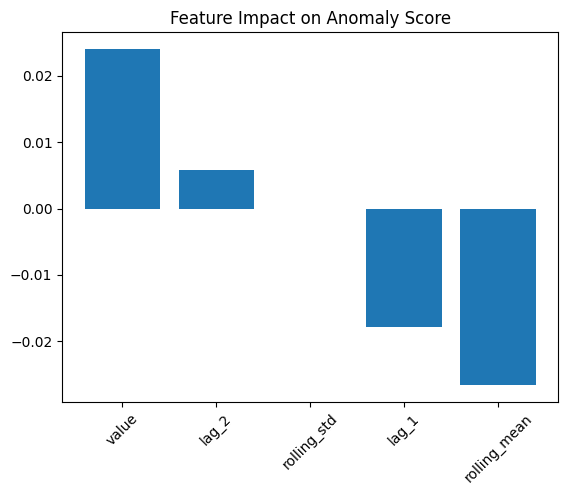

In [53]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(cf_df["feature"], cf_df["impact"])
plt.title("Feature Impact on Anomaly Score")
plt.xticks(rotation=45)
plt.show()

In [54]:
best_feature = cf_df.iloc[0]["feature"]

fixed_point = df.loc[[anomaly_index]].copy()
fixed_point[best_feature] = df[best_feature].median()

print("Fixed score:", compute_score(fixed_point))

Fixed score: -0.01268226764905045


In [55]:
# =========================
# LEVEL 5: UNCERTAINTY
# =========================

from sklearn.ensemble import IsolationForest

n_models = 10
models = []

for i in range(n_models):
    m = IsolationForest(
        n_estimators=100,
        contamination=0.1,
        random_state=42 + i
    )
    m.fit(X_scaled)
    models.append(m)

In [56]:
def get_ensemble_scores(input_df):
    X_input = scaler.transform(input_df[features])

    scores = []

    for m in models:
        score = -m.decision_function(X_input)[0]
        scores.append(score)

    return np.array(scores)

In [57]:
scores = get_ensemble_scores(df.loc[[anomaly_index]])

mean_score = scores.mean()
std_score = scores.std()

print("Scores:", scores)
print("Mean score:", mean_score)
print("Std (uncertainty):", std_score)

Scores: [0.01136299 0.01836935 0.03867595 0.0233206  0.01791296 0.04287662
 0.02200031 0.02765324 0.03542811 0.02184423]
Mean score: 0.02594443732986702
Std (uncertainty): 0.00956769500964876


In [58]:
confidence = 1 / (1 + std_score)

print("Confidence:", confidence)

Confidence: 0.9905229782441113


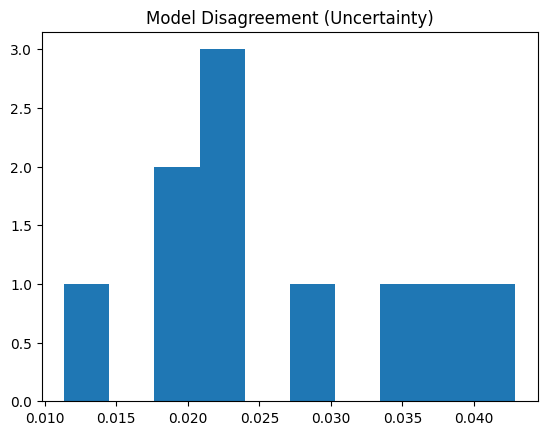

In [59]:
import matplotlib.pyplot as plt

plt.hist(scores, bins=10)
plt.title("Model Disagreement (Uncertainty)")
plt.show()

In [66]:
def generate_explanation(index):

    row = df.loc[index]

    anomaly_type = row["anomaly_type"]

    # get top feature
    top_feature = cf_df.iloc[0]["feature"]
    original_val = cf_df.iloc[0]["original"]
    new_val = cf_df.iloc[0]["counterfactual"]

    explanation = f"""
    Anomaly Type: {anomaly_type.upper()}

    Root Cause:
     The anomaly is primarily driven by '{top_feature}'.

    Actionable Fix:
     Adjust '{top_feature}' from {round(original_val,2)}
     to {round(new_val,2)} to reduce anomaly risk.

    Confidence: {round(confidence * 100, 2)}%
      """

    return explanation

In [67]:
print(generate_explanation(anomaly_index))


    Anomaly Type: DRIFT

    Root Cause:
     The anomaly is primarily driven by 'value'.

    Actionable Fix:
     Adjust 'value' from 39.8 
     to 63.22 to reduce anomaly risk.

    Confidence: 99.05%
      


In [68]:
faithfulness = baseline_score - compute_score(fixed_point)

print("Faithfulness score:", faithfulness)

Faithfulness score: 0.024045256527976955


In [69]:
stability_scores = []

for _ in range(5):

    noisy_point = df.loc[[anomaly_index]].copy()

    noise = np.random.normal(0, 0.5)
    noisy_point["value"] += noise

    score = compute_score(noisy_point)
    stability_scores.append(score)

stability = np.std(stability_scores)

print("Stability (lower is better):", stability)

Stability (lower is better): 0.00505986213282554


In [70]:
fixed_score = compute_score(fixed_point)

is_fixed = fixed_score < 0

print("Actionability (fixed?):", is_fixed)

Actionability (fixed?): True


In [71]:
feedback_log = []

In [72]:
def add_feedback(index, label):

    feedback_log.append({
        "index": index,
        "true_label": label
    })

    print("Feedback added:", index, label)

In [73]:
# suppose user says this is NOT anomaly
add_feedback(anomaly_index, 0)

Feedback added: 35 0


In [74]:
def adjust_threshold(df, feedback_log):

    corrected_normals = [f["index"] for f in feedback_log if f["true_label"] == 0]

    if len(corrected_normals) > 0:
        avg_score = df.loc[corrected_normals]["score"].mean()

        new_threshold = avg_score

        print("Adjusted threshold:", new_threshold)

        return new_threshold

    return None

In [75]:
new_threshold = adjust_threshold(df, feedback_log)

if new_threshold is not None:
    df["adjusted_pred"] = df["score"].apply(lambda x: 1 if x > new_threshold else 0)

Adjusted threshold: 0.011362988878926505


In [76]:
def run_causal_xad(input_df):

    # -------- Step 1: preprocess --------
    X_input = scaler.transform(input_df[features])

    # -------- Step 2: anomaly score --------
    score = -model.decision_function(X_input)[0]
    pred = 1 if score > 0 else 0

    # -------- Step 3: temporal type --------
    idx = input_df.index[0]
    anomaly_type = df.loc[idx]["anomaly_type"]

    # -------- Step 4: uncertainty --------
    scores = get_ensemble_scores(input_df)
    confidence = 1 / (1 + scores.std())

    # -------- Step 5: explanation --------
    explanation = generate_explanation(idx)

    return {
        "score": score,
        "prediction": pred,
        "type": anomaly_type,
        "confidence": confidence,
        "explanation": explanation
    }

In [77]:
test_input = df.loc[[anomaly_index]]

result = run_causal_xad(test_input)

for k, v in result.items():
    print(f"{k}: {v}")

score: 0.011362988878926505
prediction: 1
type: drift
confidence: 0.9905229782441113
explanation: 
    Anomaly Type: DRIFT

    Root Cause:
     The anomaly is primarily driven by 'value'.

    Actionable Fix:
     Adjust 'value' from 39.8 
     to 63.22 to reduce anomaly risk.

    Confidence: 99.05%
      


In [78]:
# Save entire notebook as python file
!jupyter nbconvert --to script /content/*.ipynb

[NbConvertApp] WARNING | pattern '/content/*.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    

In [ ]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

In [ ]:
df.to_csv("data.csv", index=False)

In [ ]:
df.to_csv("data.csv", index=False)

In [ ]:
import json

with open("features.json", "w") as f:
    json.dump(features, f)

In [ ]:
with open("sample_output.txt", "w") as f:
    f.write(str(result))

In [ ]:
from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")
files.download("data.csv")
files.download("features.json")
files.download("sample_output.txt")